# Báo cáo Phân loại Malware sử dụng Machine Learning trên bộ dữ liệu EMBER

## 1. Giới thiệu đề tài

Trong bối cảnh các cuộc tấn công mạng ngày càng gia tăng về số lượng lẫn mức độ tinh vi, việc phát hiện và phân loại mã độc (malware classification) trở thành một trong những bài toán quan trọng trong lĩnh vực an toàn thông tin. Các phương pháp truyền thống dựa trên chữ ký (signature-based detection) thường gặp khó khăn trước các biến thể malware mới hoặc các kỹ thuật obfuscation hiện đại.

Do đó, trong notebook này, nhóm triển khai một quy trình hoàn chỉnh nhằm:
- Trích xuất đặc trưng từ tập dữ liệu EMBER
- Tiền xử lý và lựa chọn đặc trưng quan trọng
- Thực hiện phân tích dữ liệu khám phá (EDA)
- Huấn luyện và đánh giá nhiều mô hình Machine Learning
- So sánh hiệu năng giữa các mô hình
- Kiểm thử trên tập dữ liệu độc lập để đánh giá khả năng tổng quát hóa

Toàn bộ pipeline được xây dựng theo hướng:
- Có khả năng mở rộng
- Dễ tái sử dụng
- Tối ưu hiệu suất xử lý dữ liệu lớn
- Phù hợp cho các bài toán malware detection thực tế

---

## 2. Mục tiêu nghiên cứu

Các mục tiêu chính của notebook bao gồm:

1. Xây dựng pipeline xử lý dữ liệu malware hoàn chỉnh
2. Khảo sát các đặc trưng quan trọng trong dữ liệu PE file
3. Đánh giá ảnh hưởng của feature selection đến hiệu năng mô hình
4. So sánh các mô hình:
   - Logistic Regression
   - Random Forest
   - LightGBM
5. Đánh giá khả năng phân loại malware thông qua:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion Matrix
6. Kiểm tra khả năng tổng quát hóa trên tập test độc lập

---

## 3. Ý nghĩa thực tiễn

Bài toán malware classification có tính ứng dụng rất cao trong:
- Antivirus systems
- Endpoint Detection & Response (EDR)
- SOC (Security Operations Center)
- Threat Intelligence
- Malware Sandbox Analysis

Việc áp dụng Machine Learning giúp:
- Phát hiện các biến thể malware chưa từng xuất hiện
- Giảm phụ thuộc vào chữ ký truyền thống
- Tăng tốc độ phát hiện
- Hỗ trợ tự động hóa quá trình phân tích mã độc

---

## 4. Tổng quan pipeline thực hiện

Pipeline tổng quát của hệ thống gồm các bước:

1. Đọc và xử lý dữ liệu JSONL từ EMBER Dataset
2. Trích xuất đặc trưng PE file
3. Chuyển đổi sang định dạng Parquet tối ưu
4. Làm sạch dữ liệu
5. Loại bỏ đặc trưng không hữu ích
6. Chọn đặc trưng quan trọng bằng LightGBM
7. Phân tích dữ liệu khám phá (EDA)
8. Huấn luyện mô hình
9. Đánh giá hiệu năng
10. Kiểm thử trên dữ liệu độc lập

---

## 5. Import thư viện

Cell dưới đây thực hiện import các thư viện cần thiết cho toàn bộ quá trình xử lý dữ liệu, trực quan hóa và huấn luyện mô hình.

In [1]:
!pip install fastparquet lief catboost xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import json
import glob
import os
import gc
import lief
import hashlib
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import FeatureHasher

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

folder_path = '/kaggle/input/datasets/hoangtnh/ember-dataset'

## 1.1 Xây dựng lớp trích xuất đặc trưng (Feature Extraction)

Trong bài toán malware classification, dữ liệu đầu vào không phải là dữ liệu dạng bảng thông thường mà là các PE file (Portable Executable) của Windows. Vì vậy, cần có cơ chế trích xuất đặc trưng để chuyển đổi các thuộc tính của file thực thi thành vector số học mà mô hình Machine Learning có thể xử lý.

### Vai trò của Feature Extraction

Feature extraction là bước cực kỳ quan trọng vì:
- Chất lượng đặc trưng quyết định trực tiếp chất lượng mô hình
- Malware thường được biểu diễn dưới dạng binary nên không thể đưa trực tiếp vào mô hình
- Cần chuyển đổi thông tin cấu trúc PE sang vector đặc trưng cố định

### Các loại đặc trưng thường được sử dụng

Notebook sử dụng nhiều nhóm đặc trưng như:
- Header information
- Imported functions
- Exported functions
- Section entropy
- Byte histogram
- String information
- Metadata của file PE

### Ý nghĩa của việc hash đặc trưng

Một số đặc trưng như:
- imported libraries
- imported functions
- exported symbols

có kích thước rất lớn và không cố định. Do đó kỹ thuật Feature Hashing được sử dụng nhằm:
- Giảm số chiều dữ liệu
- Tăng tốc độ huấn luyện
- Giữ được tính phân biệt của đặc trưng
- Tránh exploding feature space

Cell dưới đây định nghĩa các lớp phục vụ cho quá trình trích xuất đặc trưng.

In [2]:
LIEF_MAJOR, LIEF_MINOR, _ = lief.__version__.split('.')
LIEF_EXPORT_OBJECT = int(LIEF_MAJOR) > 0 or ( int(LIEF_MAJOR)==0 and int(LIEF_MINOR) >= 10 )
LIEF_HAS_SIGNATURE = int(LIEF_MAJOR) > 0 or (int(LIEF_MAJOR) == 0 and int(LIEF_MINOR) >= 11)


class FeatureType(object):
    ''' Base class from which each feature type may inherit '''

    name = ''
    dim = 0

    def __repr__(self):
        return '{}({})'.format(self.name, self.dim)

    def raw_features(self, bytez, lief_binary):
        ''' Generate a JSON-able representation of the file '''
        raise (NotImplementedError)

    def process_raw_features(self, raw_obj):
        ''' Generate a feature vector from the raw features '''
        raise (NotImplementedError)

    def feature_vector(self, bytez, lief_binary):
        ''' Directly calculate the feature vector from the sample itself. This should only be implemented differently
        if there are significant speedups to be gained from combining the two functions. '''
        return self.process_raw_features(self.raw_features(bytez, lief_binary))


class ByteHistogram(FeatureType):
    ''' Byte histogram (count + non-normalized) over the entire binary file '''

    name = 'histogram'
    dim = 256

    def __init__(self):
        super(FeatureType, self).__init__()

    def raw_features(self, bytez, lief_binary):
        counts = np.bincount(np.frombuffer(bytez, dtype=np.uint8), minlength=256)
        return counts.tolist()

    def process_raw_features(self, raw_obj):
        counts = np.array(raw_obj, dtype=np.float32)
        sum = counts.sum()
        normalized = counts / sum
        return normalized


class ByteEntropyHistogram(FeatureType):
    ''' 2d byte/entropy histogram based loosely on (Saxe and Berlin, 2015).
    This roughly approximates the joint probability of byte value and local entropy.
    See Section 2.1.1 in https://arxiv.org/pdf/1508.03096.pdf for more info.
    '''

    name = 'byteentropy'
    dim = 256

    def __init__(self, step=1024, window=2048):
        super(FeatureType, self).__init__()
        self.window = window
        self.step = step

    def _entropy_bin_counts(self, block):
        # coarse histogram, 16 bytes per bin
        c = np.bincount(block >> 4, minlength=16)  # 16-bin histogram
        p = c.astype(np.float32) / self.window
        wh = np.where(c)[0]
        H = np.sum(-p[wh] * np.log2(
            p[wh])) * 2  # * x2 b.c. we reduced information by half: 256 bins (8 bits) to 16 bins (4 bits)

        Hbin = int(H * 2)  # up to 16 bins (max entropy is 8 bits)
        if Hbin == 16:  # handle entropy = 8.0 bits
            Hbin = 15

        return Hbin, c

    def raw_features(self, bytez, lief_binary):
        output = np.zeros((16, 16), dtype=np.int)
        a = np.frombuffer(bytez, dtype=np.uint8)
        if a.shape[0] < self.window:
            Hbin, c = self._entropy_bin_counts(a)
            output[Hbin, :] += c
        else:
            # strided trick from here: http://www.rigtorp.se/2011/01/01/rolling-statistics-numpy.html
            shape = a.shape[:-1] + (a.shape[-1] - self.window + 1, self.window)
            strides = a.strides + (a.strides[-1],)
            blocks = np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)[::self.step, :]

            # from the blocks, compute histogram
            for block in blocks:
                Hbin, c = self._entropy_bin_counts(block)
                output[Hbin, :] += c

        return output.flatten().tolist()

    def process_raw_features(self, raw_obj):
        counts = np.array(raw_obj, dtype=np.float32)
        sum = counts.sum()
        normalized = counts / sum
        return normalized


class SectionInfo(FeatureType):
    ''' Information about section names, sizes and entropy.  Uses hashing trick
    to summarize all this section info into a feature vector.
    '''

    name = 'section'
    dim = 5 + 50 + 50 + 50 + 50 + 50

    def __init__(self):
        super(FeatureType, self).__init__()

    @staticmethod
    def _properties(s):
        return [str(c).split('.')[-1] for c in s.characteristics_lists]

    def raw_features(self, bytez, lief_binary):
        if lief_binary is None:
            return {"entry": "", "sections": []}

        # properties of entry point, or if invalid, the first executable section

        try:
            if int(LIEF_MAJOR) > 0 or (int(LIEF_MAJOR) == 0 and int(LIEF_MINOR) >= 12):
                section = lief_binary.section_from_rva(lief_binary.entrypoint - lief_binary.imagebase)
                if section is None:
                    raise lief.not_found
                entry_section = section.name
            else: # lief < 0.12
                entry_section = lief_binary.section_from_offset(lief_binary.entrypoint).name
        except lief.not_found:
                # bad entry point, let's find the first executable section
                entry_section = ""
                for s in lief_binary.sections:
                    if lief.PE.SECTION_CHARACTERISTICS.MEM_EXECUTE in s.characteristics_lists:
                        entry_section = s.name
                        break

        raw_obj = {"entry": entry_section}
        raw_obj["sections"] = [{
            'name': s.name,
            'size': s.size,
            'entropy': s.entropy,
            'vsize': s.virtual_size,
            'props': self._properties(s)
        } for s in lief_binary.sections]
        return raw_obj

    def process_raw_features(self, raw_obj):
        sections = raw_obj['sections']
        general = [
            len(sections),  # total number of sections
            # number of sections with zero size
            sum(1 for s in sections if s['size'] == 0),
            # number of sections with an empty name
            sum(1 for s in sections if s['name'] == ""),
            # number of RX
            sum(1 for s in sections if 'MEM_READ' in s['props'] and 'MEM_EXECUTE' in s['props']),
            # number of W
            sum(1 for s in sections if 'MEM_WRITE' in s['props'])
        ]
        # gross characteristics of each section
        section_sizes = [(s['name'], s['size']) for s in sections]
        section_sizes_hashed = FeatureHasher(50, input_type="pair").transform([section_sizes]).toarray()[0]
        section_entropy = [(s['name'], s['entropy']) for s in sections]
        section_entropy_hashed = FeatureHasher(50, input_type="pair").transform([section_entropy]).toarray()[0]
        section_vsize = [(s['name'], s['vsize']) for s in sections]
        section_vsize_hashed = FeatureHasher(50, input_type="pair").transform([section_vsize]).toarray()[0]
        entry_name_hashed = FeatureHasher(50, input_type="string").transform([[raw_obj['entry']]]).toarray()[0]
        characteristics = [p for s in sections for p in s['props'] if s['name'] == raw_obj['entry']]
        characteristics_hashed = FeatureHasher(50, input_type="string").transform([characteristics]).toarray()[0]

        return np.hstack([
            general, section_sizes_hashed, section_entropy_hashed, section_vsize_hashed, entry_name_hashed,
            characteristics_hashed
        ]).astype(np.float32)


class ImportsInfo(FeatureType):
    ''' Information about imported libraries and functions from the
    import address table.  Note that the total number of imported
    functions is contained in GeneralFileInfo.
    '''

    name = 'imports'
    dim = 1280

    def __init__(self):
        super(FeatureType, self).__init__()

    def raw_features(self, bytez, lief_binary):
        imports = {}
        if lief_binary is None:
            return imports

        for lib in lief_binary.imports:
            if lib.name not in imports:
                imports[lib.name] = []  # libraries can be duplicated in listing, extend instead of overwrite

            # Clipping assumes there are diminishing returns on the discriminatory power of imported functions
            #  beyond the first 10000 characters, and this will help limit the dataset size
            for entry in lib.entries:
                if entry.is_ordinal:
                    imports[lib.name].append("ordinal" + str(entry.ordinal))
                else:
                    imports[lib.name].append(entry.name[:10000])

        return imports

    def process_raw_features(self, raw_obj):
        # unique libraries
        libraries = list(set([l.lower() for l in raw_obj.keys()]))
        libraries_hashed = FeatureHasher(256, input_type="string").transform([libraries]).toarray()[0]

        # A string like "kernel32.dll:CreateFileMappingA" for each imported function
        imports = [lib.lower() + ':' + e for lib, elist in raw_obj.items() for e in elist]
        imports_hashed = FeatureHasher(1024, input_type="string").transform([imports]).toarray()[0]

        # Two separate elements: libraries (alone) and fully-qualified names of imported functions
        return np.hstack([libraries_hashed, imports_hashed]).astype(np.float32)


class ExportsInfo(FeatureType):
    ''' Information about exported functions. Note that the total number of exported
    functions is contained in GeneralFileInfo.
    '''

    name = 'exports'
    dim = 128

    def __init__(self):
        super(FeatureType, self).__init__()

    def raw_features(self, bytez, lief_binary):
        if lief_binary is None:
            return []

        # Clipping assumes there are diminishing returns on the discriminatory power of exports beyond
        #  the first 10000 characters, and this will help limit the dataset size
        if LIEF_EXPORT_OBJECT:
            # export is an object with .name attribute (0.10.0 and later)
            clipped_exports = [export.name[:10000] for export in lief_binary.exported_functions]
        else:
            # export is a string (LIEF 0.9.0 and earlier)
            clipped_exports = [export[:10000] for export in lief_binary.exported_functions]


        return clipped_exports

    def process_raw_features(self, raw_obj):
        exports_hashed = FeatureHasher(128, input_type="string").transform([raw_obj]).toarray()[0]
        return exports_hashed.astype(np.float32)


class GeneralFileInfo(FeatureType):
    ''' General information about the file '''

    name = 'general'
    dim = 10

    def __init__(self):
        super(FeatureType, self).__init__()

    def raw_features(self, bytez, lief_binary):
        if lief_binary is None:
            return {
                'size': len(bytez),
                'vsize': 0,
                'has_debug': 0,
                'exports': 0,
                'imports': 0,
                'has_relocations': 0,
                'has_resources': 0,
                'has_signature': 0,
                'has_tls': 0,
                'symbols': 0
            }

        return {
            'size': len(bytez),
            'vsize': lief_binary.virtual_size,
            'has_debug': int(lief_binary.has_debug),
            'exports': len(lief_binary.exported_functions),
            'imports': len(lief_binary.imported_functions),
            'has_relocations': int(lief_binary.has_relocations),
            'has_resources': int(lief_binary.has_resources),
            'has_signature': int(lief_binary.has_signatures) if LIEF_HAS_SIGNATURE else int(lief_binary.has_signature),
            'has_tls': int(lief_binary.has_tls),
            'symbols': len(lief_binary.symbols),
        }

    def process_raw_features(self, raw_obj):
        return np.asarray([
            raw_obj['size'], raw_obj['vsize'], raw_obj['has_debug'], raw_obj['exports'], raw_obj['imports'],
            raw_obj['has_relocations'], raw_obj['has_resources'], raw_obj['has_signature'], raw_obj['has_tls'],
            raw_obj['symbols']
        ],
                          dtype=np.float32)


class HeaderFileInfo(FeatureType):
    ''' Machine, architecure, OS, linker and other information extracted from header '''

    name = 'header'
    dim = 62

    def __init__(self):
        super(FeatureType, self).__init__()

    def raw_features(self, bytez, lief_binary):
        raw_obj = {}
        raw_obj['coff'] = {'timestamp': 0, 'machine': "", 'characteristics': []}
        raw_obj['optional'] = {
            'subsystem': "",
            'dll_characteristics': [],
            'magic': "",
            'major_image_version': 0,
            'minor_image_version': 0,
            'major_linker_version': 0,
            'minor_linker_version': 0,
            'major_operating_system_version': 0,
            'minor_operating_system_version': 0,
            'major_subsystem_version': 0,
            'minor_subsystem_version': 0,
            'sizeof_code': 0,
            'sizeof_headers': 0,
            'sizeof_heap_commit': 0
        }
        if lief_binary is None:
            return raw_obj

        raw_obj['coff']['timestamp'] = lief_binary.header.time_date_stamps
        raw_obj['coff']['machine'] = str(lief_binary.header.machine).split('.')[-1]
        raw_obj['coff']['characteristics'] = [str(c).split('.')[-1] for c in lief_binary.header.characteristics_list]
        raw_obj['optional']['subsystem'] = str(lief_binary.optional_header.subsystem).split('.')[-1]
        raw_obj['optional']['dll_characteristics'] = [
            str(c).split('.')[-1] for c in lief_binary.optional_header.dll_characteristics_lists
        ]
        raw_obj['optional']['magic'] = str(lief_binary.optional_header.magic).split('.')[-1]
        raw_obj['optional']['major_image_version'] = lief_binary.optional_header.major_image_version
        raw_obj['optional']['minor_image_version'] = lief_binary.optional_header.minor_image_version
        raw_obj['optional']['major_linker_version'] = lief_binary.optional_header.major_linker_version
        raw_obj['optional']['minor_linker_version'] = lief_binary.optional_header.minor_linker_version
        raw_obj['optional'][
            'major_operating_system_version'] = lief_binary.optional_header.major_operating_system_version
        raw_obj['optional'][
            'minor_operating_system_version'] = lief_binary.optional_header.minor_operating_system_version
        raw_obj['optional']['major_subsystem_version'] = lief_binary.optional_header.major_subsystem_version
        raw_obj['optional']['minor_subsystem_version'] = lief_binary.optional_header.minor_subsystem_version
        raw_obj['optional']['sizeof_code'] = lief_binary.optional_header.sizeof_code
        raw_obj['optional']['sizeof_headers'] = lief_binary.optional_header.sizeof_headers
        raw_obj['optional']['sizeof_heap_commit'] = lief_binary.optional_header.sizeof_heap_commit
        return raw_obj

    def process_raw_features(self, raw_obj):
        return np.hstack([
            raw_obj['coff']['timestamp'],
            FeatureHasher(10, input_type="string").transform([[raw_obj['coff']['machine']]]).toarray()[0],
            FeatureHasher(10, input_type="string").transform([raw_obj['coff']['characteristics']]).toarray()[0],
            FeatureHasher(10, input_type="string").transform([[raw_obj['optional']['subsystem']]]).toarray()[0],
            FeatureHasher(10, input_type="string").transform([raw_obj['optional']['dll_characteristics']]).toarray()[0],
            FeatureHasher(10, input_type="string").transform([[raw_obj['optional']['magic']]]).toarray()[0],
            raw_obj['optional']['major_image_version'],
            raw_obj['optional']['minor_image_version'],
            raw_obj['optional']['major_linker_version'],
            raw_obj['optional']['minor_linker_version'],
            raw_obj['optional']['major_operating_system_version'],
            raw_obj['optional']['minor_operating_system_version'],
            raw_obj['optional']['major_subsystem_version'],
            raw_obj['optional']['minor_subsystem_version'],
            raw_obj['optional']['sizeof_code'],
            raw_obj['optional']['sizeof_headers'],
            raw_obj['optional']['sizeof_heap_commit'],
        ]).astype(np.float32)


class StringExtractor(FeatureType):
    ''' Extracts strings from raw byte stream '''

    name = 'strings'
    dim = 1 + 1 + 1 + 96 + 1 + 1 + 1 + 1 + 1

    def __init__(self):
        super(FeatureType, self).__init__()
        # all consecutive runs of 0x20 - 0x7f that are 5+ characters
        self._allstrings = re.compile(b'[\x20-\x7f]{5,}')
        # occurances of the string 'C:\'.  Not actually extracting the path
        self._paths = re.compile(b'c:\\\\', re.IGNORECASE)
        # occurances of http:// or https://.  Not actually extracting the URLs
        self._urls = re.compile(b'https?://', re.IGNORECASE)
        # occurances of the string prefix HKEY_.  No actually extracting registry names
        self._registry = re.compile(b'HKEY_')
        # crude evidence of an MZ header (dropper?) somewhere in the byte stream
        self._mz = re.compile(b'MZ')

    def raw_features(self, bytez, lief_binary):
        allstrings = self._allstrings.findall(bytez)
        if allstrings:
            # statistics about strings:
            string_lengths = [len(s) for s in allstrings]
            avlength = sum(string_lengths) / len(string_lengths)
            # map printable characters 0x20 - 0x7f to an int array consisting of 0-95, inclusive
            as_shifted_string = [b - ord(b'\x20') for b in b''.join(allstrings)]
            c = np.bincount(as_shifted_string, minlength=96)  # histogram count
            # distribution of characters in printable strings
            csum = c.sum()
            p = c.astype(np.float32) / csum
            wh = np.where(c)[0]
            H = np.sum(-p[wh] * np.log2(p[wh]))  # entropy
        else:
            avlength = 0
            c = np.zeros((96,), dtype=np.float32)
            H = 0
            csum = 0

        return {
            'numstrings': len(allstrings),
            'avlength': avlength,
            'printabledist': c.tolist(),  # store non-normalized histogram
            'printables': int(csum),
            'entropy': float(H),
            'paths': len(self._paths.findall(bytez)),
            'urls': len(self._urls.findall(bytez)),
            'registry': len(self._registry.findall(bytez)),
            'MZ': len(self._mz.findall(bytez))
        }

    def process_raw_features(self, raw_obj):
        hist_divisor = float(raw_obj['printables']) if raw_obj['printables'] > 0 else 1.0
        return np.hstack([
            raw_obj['numstrings'], raw_obj['avlength'], raw_obj['printables'],
            np.asarray(raw_obj['printabledist']) / hist_divisor, raw_obj['entropy'], raw_obj['paths'], raw_obj['urls'],
            raw_obj['registry'], raw_obj['MZ']
        ]).astype(np.float32)


class DataDirectories(FeatureType):
    ''' Extracts size and virtual address of the first 15 data directories '''

    name = 'datadirectories'
    dim = 15 * 2

    def __init__(self):
        super(FeatureType, self).__init__()
        self._name_order = [
            "EXPORT_TABLE", "IMPORT_TABLE", "RESOURCE_TABLE", "EXCEPTION_TABLE", "CERTIFICATE_TABLE",
            "BASE_RELOCATION_TABLE", "DEBUG", "ARCHITECTURE", "GLOBAL_PTR", "TLS_TABLE", "LOAD_CONFIG_TABLE",
            "BOUND_IMPORT", "IAT", "DELAY_IMPORT_DESCRIPTOR", "CLR_RUNTIME_HEADER"
        ]

    def raw_features(self, bytez, lief_binary):
        output = []
        if lief_binary is None:
            return output

        for data_directory in lief_binary.data_directories:
            output.append({
                "name": str(data_directory.type).replace("DATA_DIRECTORY.", ""),
                "size": data_directory.size,
                "virtual_address": data_directory.rva
            })
        return output

    def process_raw_features(self, raw_obj):
        features = np.zeros(2 * len(self._name_order), dtype=np.float32)
        for i in range(len(self._name_order)):
            if i < len(raw_obj):
                features[2 * i] = raw_obj[i]["size"]
                features[2 * i + 1] = raw_obj[i]["virtual_address"]
        return features


class PEFeatureExtractor(object):
    ''' Extract useful features from a PE file, and return as a vector of fixed size. '''

    def __init__(self, feature_version=2, print_feature_warning=True, features_file=''):
        self.features = []
        features = {
                    'ByteHistogram': ByteHistogram(),
                    'ByteEntropyHistogram': ByteEntropyHistogram(),
                    'StringExtractor': StringExtractor(),
                    'GeneralFileInfo': GeneralFileInfo(),
                    'HeaderFileInfo': HeaderFileInfo(),
                    'SectionInfo': SectionInfo(),
                    'ImportsInfo': ImportsInfo(),
                    'ExportsInfo': ExportsInfo()
            }

        if os.path.exists(features_file):
            with open(features_file, encoding='utf8') as f:
                x = json.load(f)
                self.features = [features[feature] for feature in x['features'] if feature in features]
        else:
            self.features = list(features.values())

        if feature_version == 1:
            if not lief.__version__.startswith("0.8.3"):
                if print_feature_warning:
                    print(f"WARNING: EMBER feature version 1 were computed using lief version 0.8.3-18d5b75")
                    print(f"WARNING:   lief version {lief.__version__} found instead. There may be slight inconsistencies")
                    print(f"WARNING:   in the feature calculations.")
        elif feature_version == 2:
            self.features.append(DataDirectories())
            if not lief.__version__.startswith("0.9.0"):
                if print_feature_warning:
                    print(f"WARNING: EMBER feature version 2 were computed using lief version 0.9.0-")
                    print(f"WARNING:   lief version {lief.__version__} found instead. There may be slight inconsistencies")
                    print(f"WARNING:   in the feature calculations.")
        else:
            raise Exception(f"EMBER feature version must be 1 or 2. Not {feature_version}")
        self.dim = sum([fe.dim for fe in self.features])

    def raw_features(self, bytez):
        lief_errors = (lief.bad_format, lief.bad_file, lief.pe_error, lief.parser_error, lief.read_out_of_bound,
                       RuntimeError)
        try:
            lief_binary = lief.PE.parse(list(bytez))
        except lief_errors as e:
            print("lief error: ", str(e))
            lief_binary = None
        except Exception:  # everything else (KeyboardInterrupt, SystemExit, ValueError):
            raise

        features = {"sha256": hashlib.sha256(bytez).hexdigest()}
        features.update({fe.name: fe.raw_features(bytez, lief_binary) for fe in self.features})
        return features

    def process_raw_features(self, raw_obj):
        feature_vectors = [fe.process_raw_features(raw_obj[fe.name]) for fe in self.features]
        return np.hstack(feature_vectors).astype(np.float32)

    def feature_vector(self, bytez):
        return self.process_raw_features(self.raw_features(bytez))

## 1.2 Chuyển đổi dữ liệu sang định dạng Parquet

Dữ liệu EMBER ban đầu được lưu dưới định dạng JSONL (JSON Lines). Tuy nhiên:
- JSONL có tốc độ đọc chậm
- Tốn bộ nhớ
- Không tối ưu cho xử lý dữ liệu lớn

Do đó notebook chuyển đổi dữ liệu sang định dạng Parquet.

### Lý do sử dụng Parquet

Parquet là định dạng lưu trữ cột (columnar storage) với nhiều ưu điểm:
- Tốc độ đọc/ghi nhanh
- Tiết kiệm dung lượng
- Tối ưu cho Pandas và Spark
- Hỗ trợ xử lý dữ liệu lớn hiệu quả

### Quy trình thực hiện

Quy trình gồm:
1. Đọc từng file JSONL
2. Trích xuất đặc trưng
3. Chuẩn hóa dữ liệu
4. Chuyển sang DataFrame
5. Lưu thành Parquet

Việc này giúp tăng đáng kể tốc độ trong các bước huấn luyện phía sau.

In [3]:
def convert_to_parquet(directory_path, pattern, output_name):
    extractor = PEFeatureExtractor()
    jsonl_files = glob.glob(os.path.join(directory_path, pattern))
    jsonl_files.sort()
    
    first_file = True
    for file_path in jsonl_files:
        print(f"Đang xử lý: {os.path.basename(file_path)}...")
        features, labels = [], []
        with open(file_path, 'r') as f:
            for line in f:
                item = json.loads(line)
                if item['label'] != -1:
                    features.append(extractor.process_raw_features(item).astype(np.float32))
                    labels.append(item['label'])
        
        df_temp = pd.DataFrame(np.array(features), columns=[f'F{i+1}' for i in range(extractor.dim)])
        df_temp['Label'] = np.array(labels, dtype=np.int8)
        
        # Ghi nối vào file parquet
        df_temp.to_parquet(output_name, engine='fastparquet', append=(not first_file))
        first_file = False
        del df_temp, features, labels
        gc.collect()
    print(f"--- Hoàn thành! File lưu tại: {output_name} ---")

In [4]:
output_path = "/kaggle/working/train_data.parquet"
convert_to_parquet(folder_path, "train_features_*.jsonl", output_path)
df_train = pd.read_parquet("train_data.parquet")

Đang xử lý: train_features_0.jsonl...
Đang xử lý: train_features_1.jsonl...
Đang xử lý: train_features_2.jsonl...
Đang xử lý: train_features_3.jsonl...
Đang xử lý: train_features_4.jsonl...
Đang xử lý: train_features_5.jsonl...
--- Hoàn thành! File lưu tại: /kaggle/working/train_data.parquet ---


## 1.3 Khảo sát phân bố nhãn dữ liệu

Trước khi huấn luyện mô hình, cần kiểm tra sự cân bằng giữa các lớp dữ liệu.

### Ý nghĩa của việc kiểm tra phân bố nhãn

Nếu dữ liệu mất cân bằng nghiêm trọng:
- Mô hình có thể bias về lớp chiếm ưu thế
- Accuracy trở nên thiếu tin cậy
- Recall của lớp thiểu số giảm mạnh

Trong bài toán malware classification:
- Label = 1 thường đại diện cho malware
- Label = 0 thường đại diện cho benign software

### Điều cần quan sát

Ta cần đánh giá:
- Số lượng mẫu của từng lớp
- Mức độ chênh lệch
- Có cần resampling hay không

Kết quả dưới đây giúp xác định xem dataset có đủ cân bằng để huấn luyện trực tiếp hay cần áp dụng thêm kỹ thuật xử lý imbalance.

In [5]:
print(df_train['Label'].value_counts()) 
print(df_train.shape)

Label
0    300000
1    300000
Name: count, dtype: int64
(600000, 2382)


In [6]:
with open('/kaggle/input/datasets/hoangtnh/ember-dataset/train_features_0.jsonl', 'r') as f:
    sample_json = json.loads(f.readline())
    print("--- MẪU DỮ LIỆU JSON (TRÍCH ĐOẠN) ---")
    print(json.dumps(sample_json['general'], indent=2)) 

print("\n" + "="*50 + "\n")

import pandas as pd
df_sample = pd.read_parquet('/kaggle/working/train_data.parquet').head(5)
print("--- MẪU DỮ LIỆU PARQUET (5 DÒNG ĐẦU) ---")
display(df_sample.iloc[:, :10]) 

--- MẪU DỮ LIỆU JSON (TRÍCH ĐOẠN) ---
{
  "size": 3101705,
  "vsize": 380928,
  "has_debug": 0,
  "exports": 0,
  "imports": 156,
  "has_relocations": 0,
  "has_resources": 1,
  "has_signature": 0,
  "has_tls": 0,
  "symbols": 0
}


--- MẪU DỮ LIỆU PARQUET (5 DÒNG ĐẦU) ---


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,0.014676,0.004222,0.003923,0.004029,0.004007,0.003775,0.003825,0.003887,0.004153,0.003804
1,0.184524,0.031308,0.005693,0.005959,0.008144,0.003512,0.005786,0.008550,0.009141,0.001791
2,0.251737,0.014205,0.006841,0.008556,0.023493,0.002858,0.003401,0.008556,0.010215,0.001176
3,0.008964,0.004055,0.003925,0.003936,0.004037,0.003878,0.003847,0.003946,0.003939,0.003834
4,0.020401,0.005213,0.004519,0.004097,0.004240,0.004029,0.003785,0.004593,0.004875,0.003780


## 2. Tiền xử lý dữ liệu và làm sạch đặc trưng

Dữ liệu malware thường chứa:
- Nhiễu
- Giá trị thiếu
- Đặc trưng không mang thông tin
- Feature có độ biến thiên thấp

Nếu không xử lý trước:
- Mô hình dễ overfit
- Tăng thời gian huấn luyện
- Giảm khả năng tổng quát hóa

### Mục tiêu của bước preprocessing

Bước này nhằm:
- Giảm số chiều dữ liệu
- Loại bỏ đặc trưng vô nghĩa
- Tăng chất lượng feature space
- Giúp mô hình học ổn định hơn

### Chiến lược được sử dụng

Notebook thực hiện:
1. Sampling dữ liệu để EDA nhanh hơn
2. Loại bỏ feature constant
3. Loại bỏ feature có variance thấp
4. Chuẩn hóa cấu trúc dữ liệu

### Tại sao dùng sample 100,000 dòng?

Do dữ liệu EMBER rất lớn nên:
- EDA toàn bộ dữ liệu sẽ tốn RAM
- Visualization trở nên chậm
- Sampling giúp tăng tốc nhưng vẫn giữ được xu hướng phân bố chung

Cell dưới đây bắt đầu quá trình preprocessing.

In [7]:
# Lấy ngẫu nhiên 50,000 mẫu để làm EDA
df_sample = df_train.sample(n=100000, random_state=42)

## 2.1 Loại bỏ đặc trưng không hữu ích

Một số feature có:
- Giá trị giống nhau ở gần như toàn bộ mẫu
- Không đóng góp khả năng phân biệt
- Chỉ làm tăng nhiễu cho mô hình

### Constant Features

Constant features là các đặc trưng:
- Chỉ có một giá trị duy nhất
- Không mang thông tin phân loại

Ví dụ:
- Một cột mà mọi giá trị đều bằng 0

Các feature này cần loại bỏ vì:
- Không hỗ trợ mô hình học
- Làm tăng dimensionality
- Tăng thời gian xử lý

### Low Variance Features

Các feature có variance quá thấp:
- Gần như không thay đổi giữa các mẫu
- Khả năng phân biệt rất yếu

Việc loại bỏ giúp:
- Giảm overfitting
- Tăng tốc training
- Cải thiện khả năng tổng quát hóa

In [8]:
constant_cols = [col for col in df_sample.columns if df_sample[col].nunique() <= 1]
print(f"Số lượng cột bị loại bỏ vì không chứa thông tin: {len(constant_cols)}")

df_filtered = df_sample.drop(columns=constant_cols)
print(df_filtered.shape)

Số lượng cột bị loại bỏ vì không chứa thông tin: 40
(100000, 2342)


# 3. Lựa chọn đặc trưng bằng XGBoost

Sau bước preprocessing, dữ liệu vẫn còn hàng nghìn đặc trưng.

Vấn đề của dữ liệu nhiều chiều

High-dimensional data có thể gây:

- Curse of dimensionality
- Overfitting
- Training chậm
- Mô hình khó học được pattern quan trọng
- Tại sao chọn XGBoost để feature selection?

XGBoost là thuật toán gradient boosting mạnh, thường được sử dụng trong các bài toán machine learning nhờ khả năng:

- Xử lý tốt dữ liệu dạng bảng
- Mô hình hóa được quan hệ phi tuyến giữa các đặc trưng
- Đánh giá feature importance hiệu quả
- Có khả năng chống overfitting thông qua regularization
- Hoạt động tốt trong các bài toán phân loại như malware detection

Ý tưởng thực hiện:
- Huấn luyện XGBoost trên toàn bộ feature
- Tính importance score của từng feature
- Sắp xếp feature theo độ quan trọng
- Chọn Top 200 feature mạnh nhất

Việc chọn feature giúp:
- Giảm tài nguyên tính toán
- Tăng tốc quá trình huấn luyện và inference
- Loại bỏ các feature nhiễu hoặc ít đóng góp
- Giúp mô hình tập trung vào các pattern quan trọng hơn
- Hỗ trợ mô hình tổng quát hóa tốt hơn trên dữ liệu mới

Đây là một bước quan trọng trong pipeline malware detection, vì XGBoost không chỉ đóng vai trò mô hình phân loại mà còn được tận dụng để xác định những đặc trưng có ảnh hưởng lớn nhất đến quyết định của mô hình.

In [9]:
import xgboost as xgb

X = df_filtered.drop(columns=['Label'])
y = df_filtered['Label']

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    tree_method='hist',
    device="cpu",
    importance_type='gain',
    random_state=42,
)
model.fit(X, y)

# Lấy đặc trưng quan trọng (Feature Importance)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Giữ lại Top 200 đặc trưng tốt nhất
top_200_features = importance_df.head(200)['Feature'].tolist()
print("Đã chọn xong 200 đặc trưng quan trọng nhất!")

del df_filtered, X, y
gc.collect()

Đã chọn xong 200 đặc trưng quan trọng nhất!


53

## 3.1 Phân tích Feature Importance

Biểu đồ dưới đây thể hiện các đặc trưng có mức độ ảnh hưởng cao nhất đến quyết định của mô hình.

### Ý nghĩa của Feature Importance

Feature importance cho biết:
- Đặc trưng nào đóng góp mạnh vào quá trình phân loại
- Mô hình đang học từ thông tin nào
- Những pattern nào có liên quan đến malware

### Các insight có thể rút ra

Từ biểu đồ ta có thể:
- Xác định nhóm đặc trưng quan trọng nhất
- Phân tích hành vi của malware
- Hiểu rõ hơn cách mô hình ra quyết định

### Giá trị trong thực tế

Trong an toàn thông tin, interpretability rất quan trọng vì:
- Chuyên gia SOC cần hiểu lý do cảnh báo
- Hỗ trợ threat hunting
- Tăng khả năng explainability của hệ thống AI security

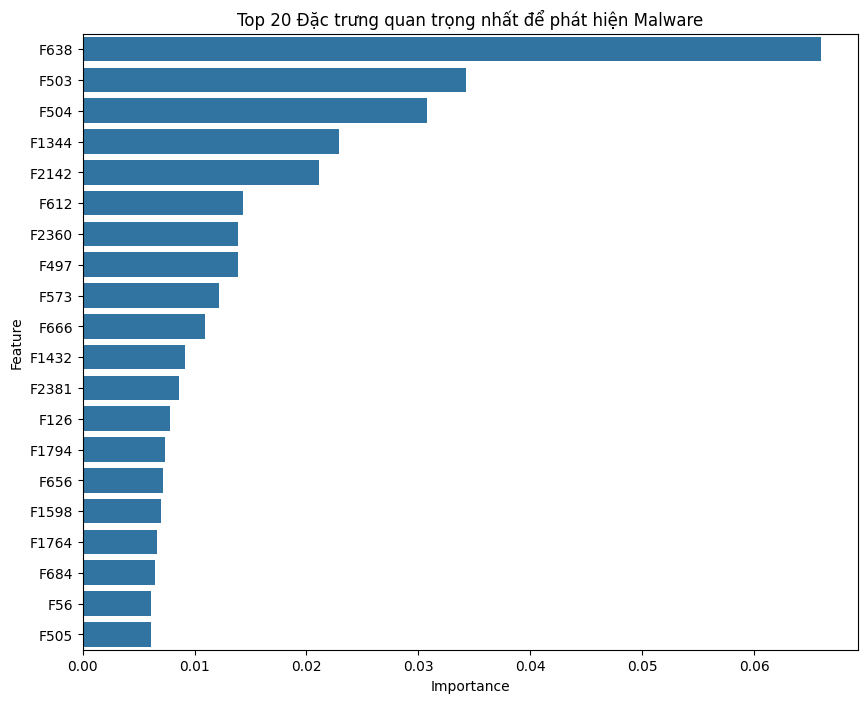

In [10]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Đặc trưng quan trọng nhất để phát hiện Malware')
plt.show()

## 4. Phân tích dữ liệu khám phá (EDA)

Sau khi xác định được các feature quan trọng, notebook tiến hành EDA để:
- Hiểu rõ phân bố dữ liệu
- Quan sát sự khác biệt giữa malware và benign
- Kiểm tra khả năng phân tách của feature

### KDE Plot

Kernel Density Estimation giúp:
- Mô phỏng phân bố xác suất
- So sánh hai lớp dữ liệu
- Quan sát mức độ overlap

### Điều cần chú ý

Nếu hai phân bố:
- Tách biệt rõ → feature mạnh
- Chồng lấn nhiều → feature yếu

### Ý nghĩa

EDA giúp:
- Đánh giá trực quan chất lượng feature
- Hỗ trợ giải thích kết quả mô hình
- Phát hiện dữ liệu bất thường

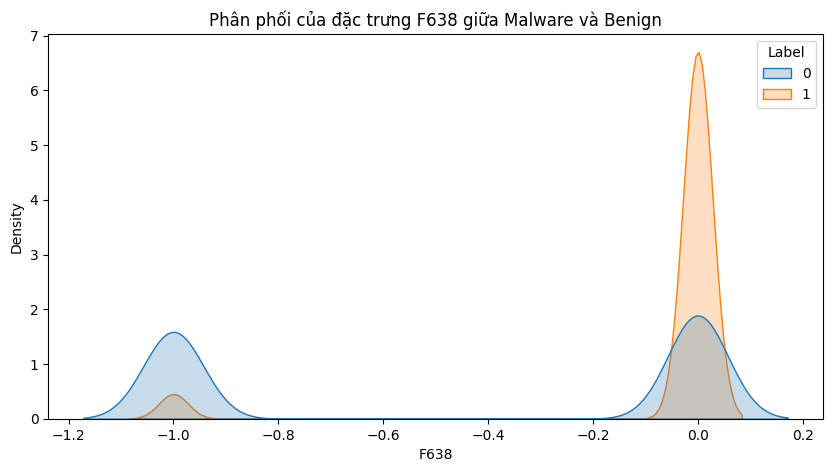

In [11]:
top_1 = top_200_features[0]
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_sample, x=top_1, hue='Label', fill=True)
plt.title(f'Phân phối của đặc trưng {top_1} giữa Malware và Benign')
plt.show()

In [12]:
features_to_keep = top_200_features + ['Label']
df_final = df_train[features_to_keep]

print("Shape:", df_train.shape)

print("\nNull count mỗi cột:")
print(df_train.isnull().sum())

print("\nTổng số null:")
print(df_train.isnull().sum().sum())

print("\nSố dòng duplicate:")
print(df_train.duplicated().sum())

print("\nTỷ lệ duplicate:")
print(df_train.duplicated().mean())

desc = df_train.drop(columns=["Label"]).describe().T
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].head(20))

Shape: (600000, 2382)

Null count mỗi cột:
F1       0
F2       0
F3       0
F4       0
F5       0
        ..
F2378    0
F2379    0
F2380    0
F2381    0
Label    0
Length: 2382, dtype: int64

Tổng số null:
0

Số dòng duplicate:
80

Tỷ lệ duplicate:
0.00013333333333333334


## 4.1 Label count distribution

Label
0    300000
1    300000
Name: count, dtype: int64


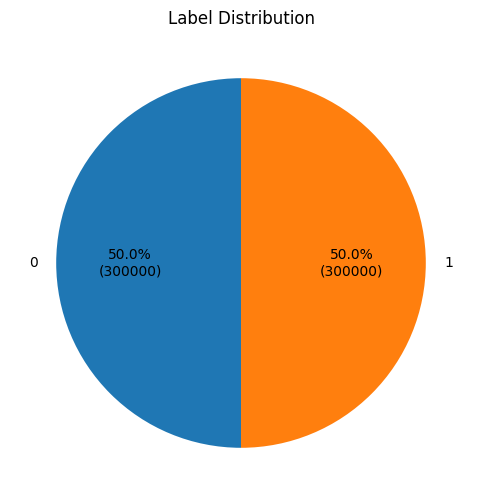

In [13]:
label_dist = df_train["Label"].value_counts().sort_index()

print(label_dist)

plt.figure(figsize=(6, 6))
plt.pie(
    label_dist.values,
    labels=label_dist.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100 * label_dist.sum()))})",
    startangle=90
)
plt.title("Label Distribution")
plt.show()

## 4.2 Phân tích tương quan giữa các đặc trưng

Heatmap correlation được sử dụng để:
- Phát hiện feature redundancy
- Quan sát mối quan hệ tuyến tính
- Đánh giá multicollinearity

### Tại sao correlation quan trọng?

Nếu nhiều feature:
- Tương quan quá cao
- Mang thông tin trùng lặp

thì:
- Mô hình có thể học dư thừa
- Training chậm hơn
- Một số thuật toán tuyến tính bị ảnh hưởng

### Ý nghĩa của heatmap

Heatmap giúp:
- Xác định nhóm feature liên quan
- Hỗ trợ feature engineering
- Đánh giá cấu trúc dữ liệu tổng thể

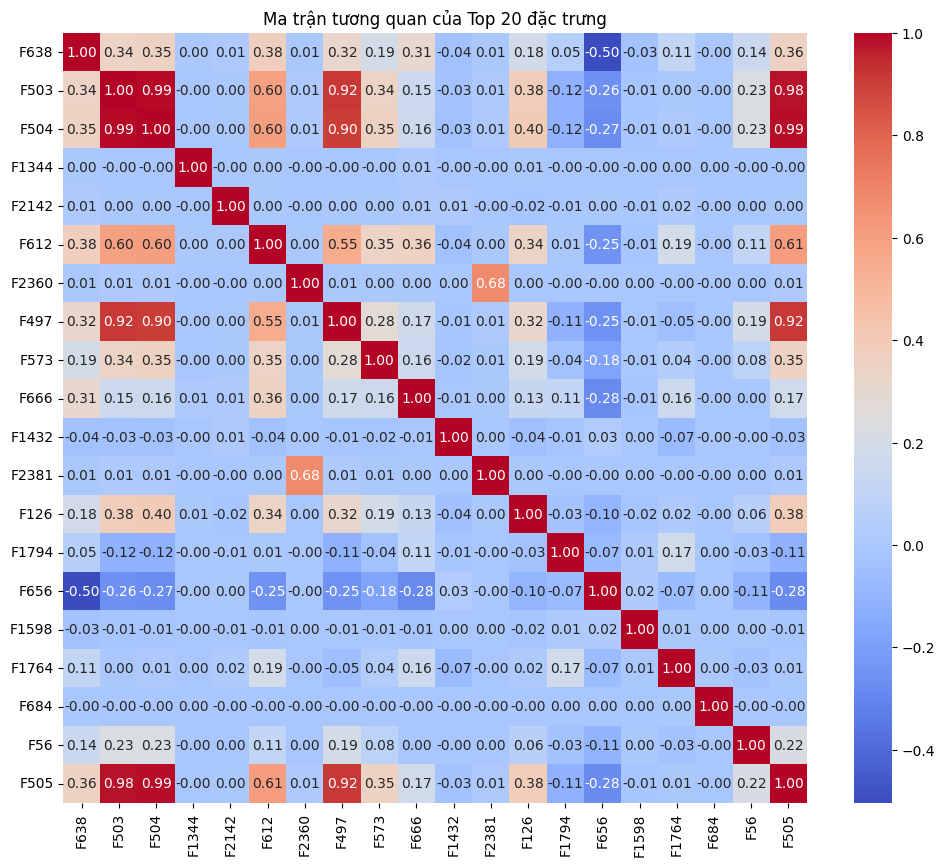

In [14]:
top_20 = top_200_features[:20]
corr_matrix = df_final[top_20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan của Top 20 đặc trưng")
plt.show()

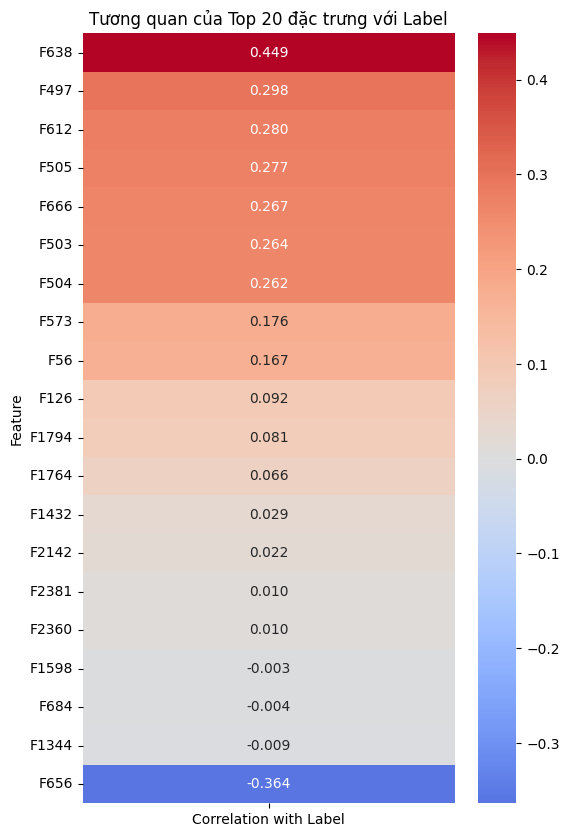

In [15]:
top_20 = top_200_features[:20]

corr_with_label = df_final[top_20 + ["Label"]].corr()["Label"].drop("Label")

corr_with_label = corr_with_label.sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_with_label.to_frame(name="Correlation with Label"),
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    center=0
)

plt.title("Tương quan của Top 20 đặc trưng với Label")
plt.xlabel("")
plt.ylabel("Feature")
plt.show()

## 5. Chia tập dữ liệu và chuẩn bị huấn luyện

Trước khi huấn luyện mô hình, dữ liệu được chia thành:
- Training set
- Validation set

### Vai trò của train/validation split

Training set:
- Dùng để mô hình học pattern

Validation set:
- Dùng để đánh giá khả năng tổng quát hóa
- Phát hiện overfitting

### Ý nghĩa của random_state

Sử dụng random_state cố định giúp:
- Đảm bảo reproducibility
- Kết quả có thể tái hiện
- Dễ so sánh giữa các lần chạy

### Tại sao cần stratify?

Trong bài toán classification, stratify giúp:
- Giữ nguyên tỷ lệ lớp giữa train và validation
- Tránh lệch phân bố dữ liệu
- Đảm bảo đánh giá công bằng

In [16]:
X = df_final.drop(columns=['Label'])
y = df_final['Label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## 6. Huấn luyện và so sánh mô hình Machine Learning

Notebook triển khai ba mô hình phổ biến trong bài toán classification:

### 1. Logistic Regression
Ưu điểm:
- Đơn giản
- Dễ giải thích
- Training nhanh

Nhược điểm:
- Khó học quan hệ phi tuyến
- Hiệu năng giới hạn trên dữ liệu phức tạp

---

### 2. Random Forest
Ưu điểm:
- Khả năng tổng quát tốt
- Chống overfitting khá tốt
- Hoạt động mạnh trên dữ liệu tabular

Nhược điểm:
- Tốn tài nguyên hơn Logistic Regression
- Inference có thể chậm khi nhiều cây

---

### 3. LightGBM
Ưu điểm:
- Huấn luyện rất nhanh
- Hiệu năng cao
- Tối ưu cho dữ liệu lớn
- Khả năng xử lý feature phức tạp rất mạnh

Nhược điểm:
- Cần tuning để tối ưu tối đa
- Khó giải thích hơn Logistic Regression

---

### 4. AdaBoost

Ưu điểm:

- Dễ triển khai
- Tăng hiệu năng bằng cách kết hợp nhiều weak learners
- Tập trung học tốt hơn trên các mẫu bị phân loại sai
- Phù hợp làm baseline boosting đơn giản

Nhược điểm:

- Nhạy cảm với noise và outlier
- Có thể kém hiệu quả hơn các boosting hiện đại như XGBoost, LightGBM, CatBoost
- Training có thể chậm nếu số lượng estimator lớn

### 5. Catboost
Ưu điểm:

- Là mô hình gradient boosting mạnh
- Hoạt động tốt trên dữ liệu tabular
- Có khả năng chống overfitting tốt
- Ít cần tuning hơn so với một số boosting model khác
- Thường cho hiệu năng cao trong các bài toán classification

Nhược điểm:

- Training có thể chậm hơn LightGBM
- Mô hình khó giải thích hơn Logistic Regression
- Có thể tốn tài nguyên nếu dataset lớn

### 6. XGBoost

Ưu điểm:

- Là một trong những thuật toán boosting phổ biến và mạnh nhất
- Hiệu năng cao trên dữ liệu tabular
- Có regularization giúp giảm overfitting
- Hỗ trợ feature importance
- Phù hợp với bài toán malware detection do khả năng học pattern phức tạp

Nhược điểm:

- Cần tuning để đạt hiệu năng tốt nhất
- Training có thể chậm hơn LightGBM trên dữ liệu rất lớn
- Nhiều hyperparameter nên khó tối ưu với người mới

### Chiến lược đánh giá

Các mô hình được đánh giá dựa trên:
- Accuracy
- Precision
- Recall
- F1-score

Đặc biệt trong malware detection:
- Recall rất quan trọng vì bỏ sót malware có thể gây hậu quả nghiêm trọng
- Precision cũng cần cao để giảm false alarm

--- Đang huấn luyện Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Đang huấn luyện Random Forest ---
--- Đang huấn luyện LightGBM ---
[LightGBM] [Info] Number of positive: 239929, number of negative: 240071
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.714892 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23427
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499852 -> initscore=-0.000592
[LightGBM] [Info] Start training from score -0.000592


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Đang huấn luyện AdaBoost ---
--- Đang huấn luyện CatBoost ---
--- Đang huấn luyện XGBoost ---


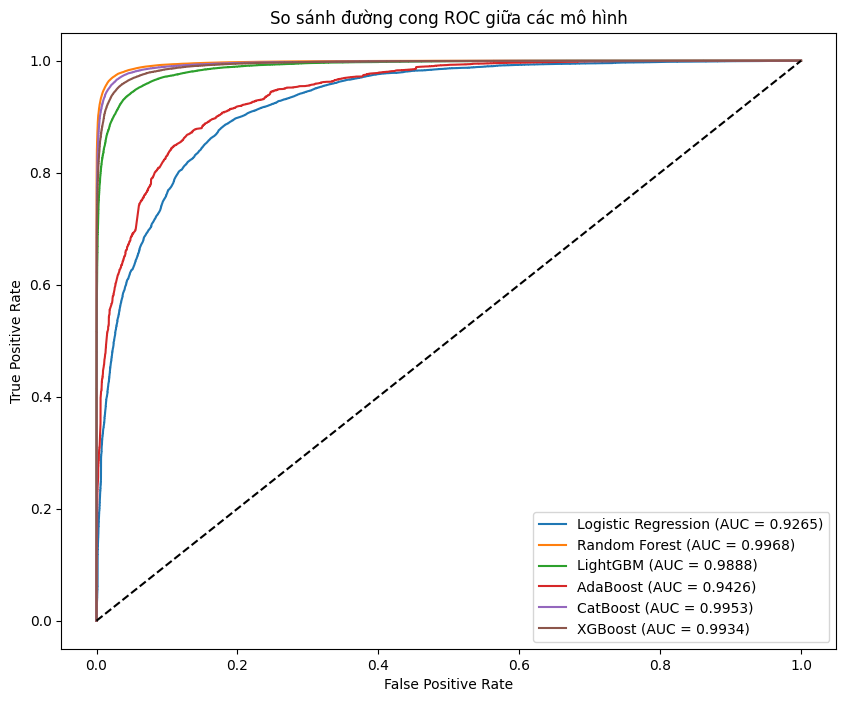


BẢNG TỔNG HỢP KẾT QUẢ TRÊN TẬP VALIDATION:


,Accuracy,Precision,Recall,F1-score,ROC AUC
Random Forest,0.973575,0.978280,0.968720,0.973477,0.996814
CatBoost,0.968442,0.969613,0.967272,0.968441,0.995301
XGBoost,0.960492,0.960316,0.960780,0.960548,0.993444
LightGBM,0.946483,0.944902,0.948394,0.946645,0.988829
AdaBoost,0.865267,0.855438,0.879476,0.867290,0.942611
Logistic Regression,0.851442,0.832421,0.880491,0.855781,0.926539


In [17]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        random_seed=42,
        verbose=0
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_jobs=-1
    )
}



results = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"--- Đang huấn luyện {name} ---")
    
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_val_scaled)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_probs = y_pred

    auc = roc_auc_score(y_val, y_probs)
    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC AUC": auc
    }

    fpr, tpr, _ = roc_curve(y_val, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh đường cong ROC giữa các mô hình")
plt.legend()
plt.show()

print("\nBẢNG TỔNG HỢP KẾT QUẢ TRÊN TẬP VALIDATION:")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="ROC AUC", ascending=False)

display(results_df)

In [18]:
baseline_results_df = results_df.copy()
baseline_results_df["Type"] = "Baseline"

display(baseline_results_df.round(4))

,Accuracy,Precision,Recall,F1-score,ROC AUC,Type
Random Forest,0.9736,0.9783,0.9687,0.9735,0.9968,Baseline
CatBoost,0.9684,0.9696,0.9673,0.9684,0.9953,Baseline
XGBoost,0.9605,0.9603,0.9608,0.9605,0.9934,Baseline
LightGBM,0.9465,0.9449,0.9484,0.9466,0.9888,Baseline
AdaBoost,0.8653,0.8554,0.8795,0.8673,0.9426,Baseline
Logistic Regression,0.8514,0.8324,0.8805,0.8558,0.9265,Baseline


In [19]:
baseline_results_df.to_csv("/kaggle/working/baseline_results.csv")

## 6.1 Tổng hợp kết quả mô hình

Bảng dưới đây tổng hợp hiệu năng của các mô hình sau quá trình huấn luyện.

### Ý nghĩa của từng metric

#### Accuracy
Tỷ lệ dự đoán đúng trên toàn bộ dữ liệu.

Tuy nhiên:
- Không phải lúc nào cũng đáng tin nếu dữ liệu mất cân bằng.

---

#### Precision
Trong các mẫu dự đoán là malware:
- Có bao nhiêu mẫu thực sự là malware.

Precision cao giúp:
- Giảm false positive
- Tránh cảnh báo giả

---

#### Recall
Trong các malware thực sự:
- Mô hình phát hiện được bao nhiêu.

Recall cao cực kỳ quan trọng trong cybersecurity vì:
- False negative rất nguy hiểm
- Malware bị bỏ sót có thể gây thiệt hại lớn

---

#### F1-score
Là trung bình điều hòa giữa Precision và Recall.

F1-score cao cho thấy:
- Mô hình cân bằng tốt giữa phát hiện malware và giảm cảnh báo giả

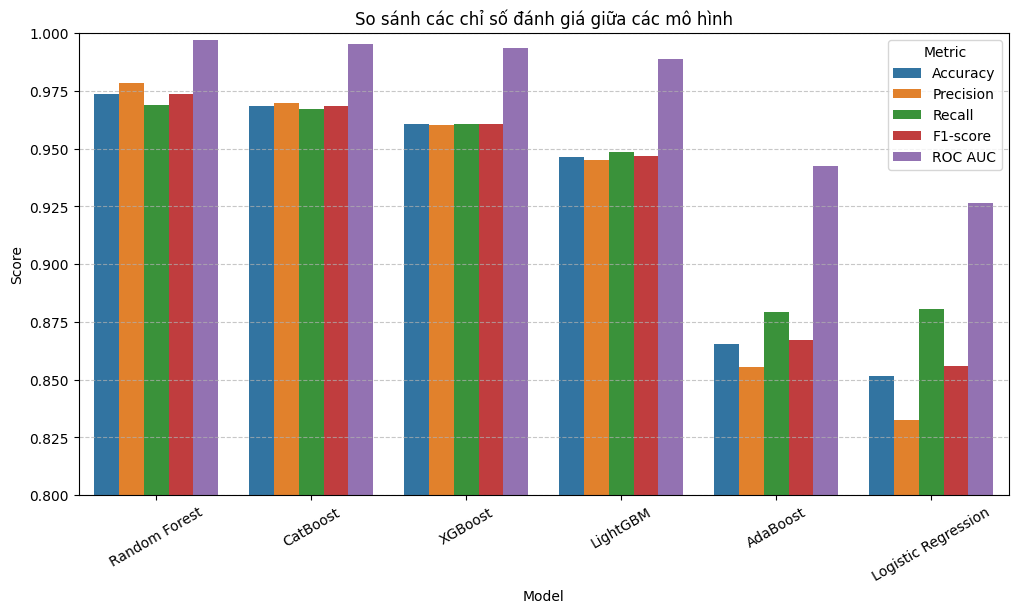

In [20]:
res_df = results_df.reset_index().rename(columns={"index": "Model"})

res_df_melted = res_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=res_df_melted, x="Model", y="Score", hue="Metric")

plt.ylim(0.8, 1.0)
plt.title("So sánh các chỉ số đánh giá giữa các mô hình")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Metric")
plt.show()

## 7. Đánh giá trực quan mô hình

Confusion Matrix giúp đánh giá chi tiết hiệu năng của mô hình.

### Các thành phần của Confusion Matrix

- True Positive (TP):
  Malware được phát hiện đúng

- True Negative (TN):
  Benign được phân loại đúng

- False Positive (FP):
  Benign bị nhận nhầm thành malware

- False Negative (FN):
  Malware bị bỏ sót

### Ý nghĩa trong an toàn thông tin

Trong cybersecurity:
- FN nguy hiểm hơn FP
- Một malware bị bỏ sót có thể gây hậu quả nghiêm trọng

Do đó:
- Recall thường được ưu tiên cao
- Tuy nhiên FP quá lớn cũng gây alert fatigue cho SOC analyst

### Giá trị của visualization

Việc trực quan hóa confusion matrix giúp:
- Dễ phân tích lỗi mô hình
- So sánh trực tiếp giữa các thuật toán
- Hiểu rõ điểm mạnh/yếu của từng mô hình

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


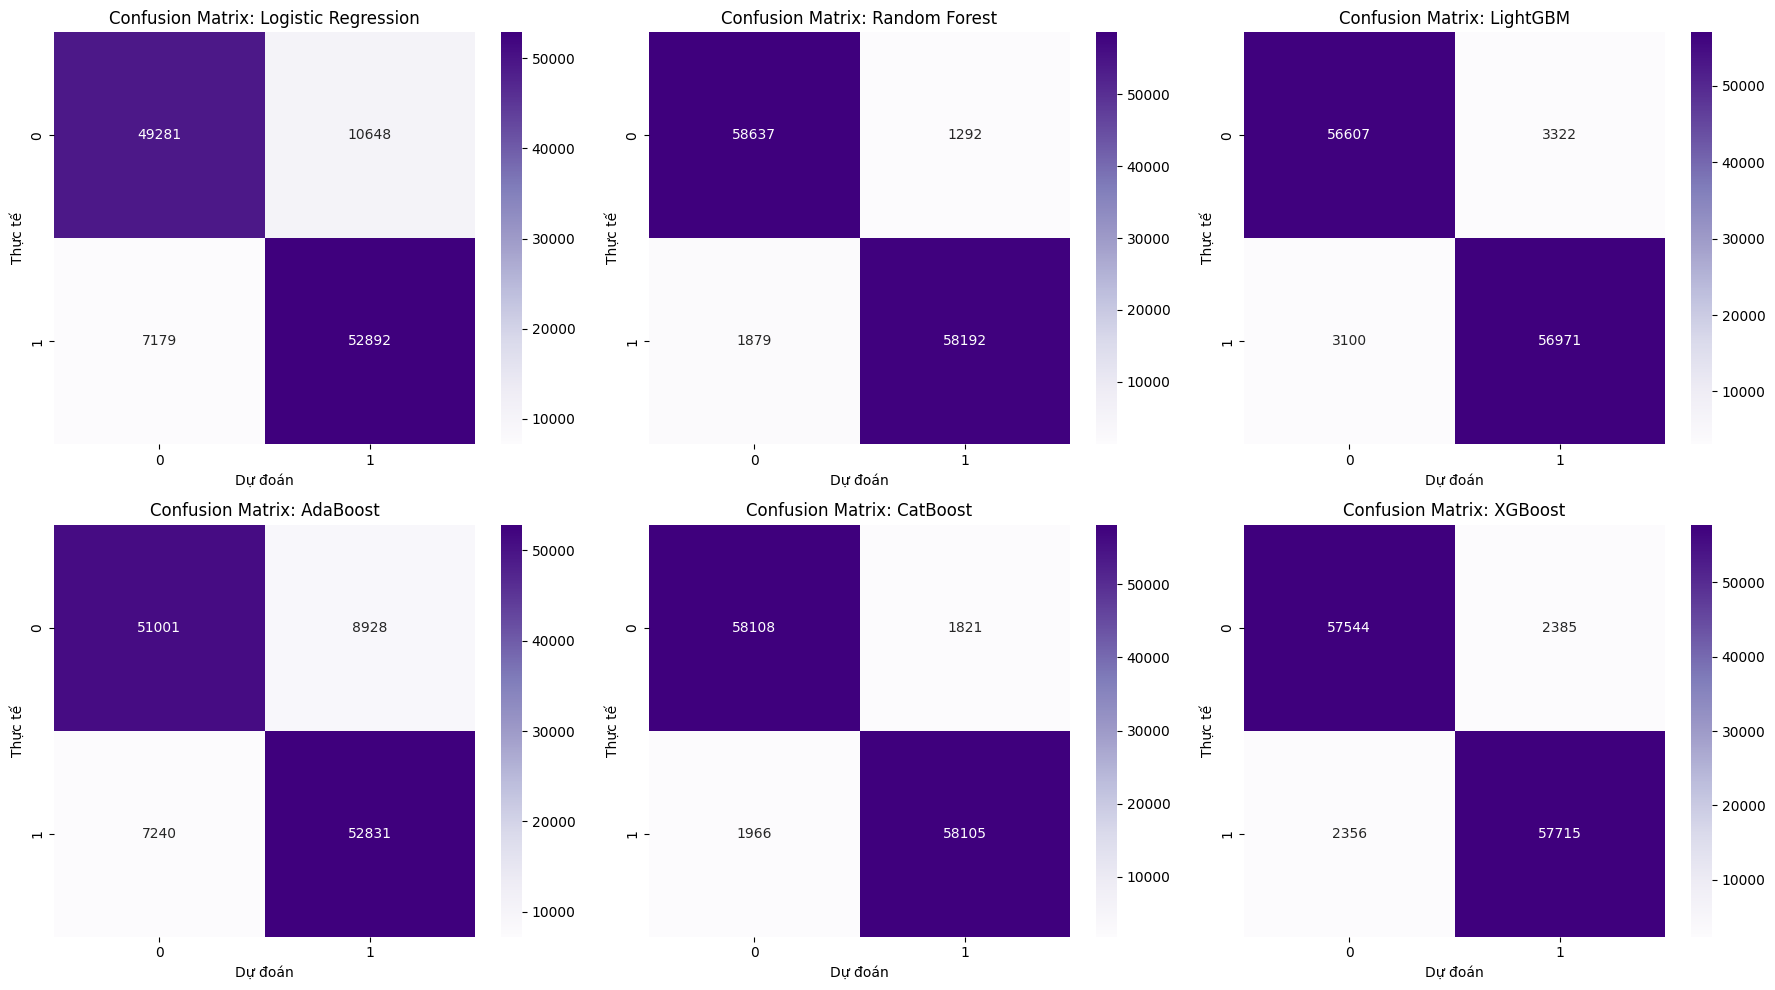

In [21]:
n_models = len(models)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val_scaled)
    cm = confusion_matrix(y_val, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Purples",
        ax=axes[i]
    )

    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Dự đoán")
    axes[i].set_ylabel("Thực tế")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 8. Tối ưu kết quả model: Hyperparameter Tuning 

In [22]:
# import warnings
# warnings.filterwarnings("ignore")

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.base import clone
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     roc_curve,
#     confusion_matrix
# )

# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# import lightgbm as lgb
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

# try:
#     import optuna
# except:
#     !pip install optuna -q
#     import optuna

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# N_TRIALS = 3

# baseline_results_df = results_df.copy()
# baseline_results_df["Type"] = "Baseline"

# baseline_models = models.copy()

# def get_probs(model, X):
#     if hasattr(model, "predict_proba"):
#         return model.predict_proba(X)[:, 1]
#     return model.predict(X)

# def evaluate_fitted_model(model, X_val, y_val):
#     y_pred = model.predict(X_val)
#     y_probs = get_probs(model, X_val)

#     return {
#         "Accuracy": accuracy_score(y_val, y_pred),
#         "Precision": precision_score(y_val, y_pred, zero_division=0),
#         "Recall": recall_score(y_val, y_pred, zero_division=0),
#         "F1-score": f1_score(y_val, y_pred, zero_division=0),
#         "ROC AUC": roc_auc_score(y_val, y_probs)
#     }
# def objective_logreg(trial):
#     params = {
#         "C": trial.suggest_categorical("C", [0.01, 0.1, 1, 10]),
#         "penalty": trial.suggest_categorical("penalty", ["l2"]),
#         "solver": "liblinear",
#         "random_state": 42,
#         "max_iter": 1000
#     }

#     model = LogisticRegression(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)


# def objective_rf(trial):
#     params = {
#         "n_estimators": trial.suggest_categorical("n_estimators", [100, 200]),
#         "max_depth": trial.suggest_categorical("max_depth", [10, 20, None]),
#         "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5]),
#         "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 2]),
#         "max_features": "sqrt",
#         "n_jobs": -1,
#         "random_state": 42
#     }

#     model = RandomForestClassifier(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)


# def objective_lgbm(trial):
#     params = {
#         "n_estimators": trial.suggest_categorical("n_estimators", [100, 200, 300]),
#         "learning_rate": trial.suggest_categorical("learning_rate", [0.03, 0.05, 0.1]),
#         "num_leaves": trial.suggest_categorical("num_leaves", [31, 63]),
#         "max_depth": trial.suggest_categorical("max_depth", [-1, 8, 12]),
#         "subsample": trial.suggest_categorical("subsample", [0.8, 1.0]),
#         "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.8, 1.0]),
#         "random_state": 42,
#         "n_jobs": -1,
#         "verbose": -1
#     }

#     model = lgb.LGBMClassifier(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)


# def objective_adaboost(trial):
#     params = {
#         "n_estimators": trial.suggest_categorical("n_estimators", [50, 100]),
#         "learning_rate": trial.suggest_categorical("learning_rate", [0.5, 1.0]),
#         "random_state": 42
#     }

#     model = AdaBoostClassifier(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)


# def objective_catboost(trial):
#     params = {
#         "iterations": trial.suggest_categorical("iterations", [100, 200]),
#         "learning_rate": trial.suggest_categorical("learning_rate", [0.03, 0.05, 0.1]),
#         "depth": trial.suggest_categorical("depth", [4, 6, 8]),
#         "l2_leaf_reg": trial.suggest_categorical("l2_leaf_reg", [1, 3, 5]),
#         "loss_function": "Logloss",
#         "eval_metric": "AUC",
#         "random_seed": 42,
#         "verbose": 0
#     }

#     model = CatBoostClassifier(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)


# def objective_xgb(trial):
#     params = {
#         "n_estimators": trial.suggest_categorical("n_estimators", [100, 200, 300]),
#         "learning_rate": trial.suggest_categorical("learning_rate", [0.03, 0.05, 0.1]),
#         "max_depth": trial.suggest_categorical("max_depth", [4, 6, 8]),
#         "subsample": trial.suggest_categorical("subsample", [0.8, 1.0]),
#         "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.8, 1.0]),
#         "objective": "binary:logistic",
#         "eval_metric": "logloss",
#         "random_state": 42,
#         "n_jobs": -1
#     }

#     model = XGBClassifier(**params)
#     model.fit(X_train_scaled, y_train)

#     y_probs = model.predict_proba(X_val_scaled)[:, 1]
#     return roc_auc_score(y_val, y_probs)

# objectives = {
#     "Logistic Regression": objective_logreg,
#     "Random Forest": objective_rf,
#     "LightGBM": objective_lgbm,
#     "AdaBoost": objective_adaboost,
#     "CatBoost": objective_catboost,
#     "XGBoost": objective_xgb
# }

# studies = {}
# best_params = {}

# for name, objective in objectives.items():
#     print(f"\n--- Đang optimize {name} bằng Optuna ---")
#     study = optuna.create_study(
#         direction="maximize",
#         sampler=optuna.samplers.TPESampler(seed=42)
#     )
#     study.optimize(objective, n_trials=N_TRIALS)

#     studies[name] = study
#     best_params[name] = study.best_params

#     print("Best ROC AUC:", study.best_value)
#     print("Best params:", study.best_params)

# optimized_models = {
#     "Logistic Regression": LogisticRegression(
#         **best_params["Logistic Regression"],
#         solver="liblinear",
#         random_state=42,
#         max_iter=2000
#     ),

#     "Random Forest": RandomForestClassifier(
#         **best_params["Random Forest"],
#         n_jobs=-1,
#         random_state=42
#     ),

#     "LightGBM": lgb.LGBMClassifier(
#         **best_params["LightGBM"],
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     ),

#     "AdaBoost": AdaBoostClassifier(
#         **best_params["AdaBoost"],
#         random_state=42
#     ),

#     "CatBoost": CatBoostClassifier(
#         **best_params["CatBoost"],
#         loss_function="Logloss",
#         eval_metric="AUC",
#         random_seed=42,
#         verbose=0
#     ),

#     "XGBoost": XGBClassifier(
#         **best_params["XGBoost"],
#         objective="binary:logistic",
#         eval_metric="logloss",
#         random_state=42,
#         n_jobs=-1
#     )
# }

# optimized_results = {}

# plt.figure(figsize=(10, 8))

# for name, model in optimized_models.items():
#     print(f"\n--- Train lại optimized {name} ---")
#     model.fit(X_train_scaled, y_train)

#     metrics = evaluate_fitted_model(model, X_val_scaled, y_val)
#     optimized_results[name] = metrics

#     y_probs = get_probs(model, X_val_scaled)
#     fpr, tpr, _ = roc_curve(y_val, y_probs)

#     plt.plot(fpr, tpr, label=f"{name} Optimized (AUC = {metrics['ROC AUC']:.4f})")

# plt.plot([0, 1], [0, 1], "k--")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve của các mô hình sau khi tối ưu bằng Optuna")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# optimized_results_df = pd.DataFrame(optimized_results).T
# optimized_results_df = optimized_results_df.sort_values(by="ROC AUC", ascending=False)
# optimized_results_df["Type"] = "Optimized"

# comparison_df = pd.concat([
#     baseline_results_df,
#     optimized_results_df
# ])

# comparison_df = comparison_df.reset_index().rename(columns={"index": "Model"})

# print("\nBẢNG SO SÁNH BASELINE VS OPTIMIZED:")
# display(comparison_df.round(4))

# metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]

# comparison_melted = comparison_df.melt(
#     id_vars=["Model", "Type"],
#     value_vars=metric_cols,
#     var_name="Metric",
#     value_name="Score"
# )

# plt.figure(figsize=(14, 7))
# sns.barplot(
#     data=comparison_melted,
#     x="Model",
#     y="Score",
#     hue="Type"
# )
# plt.ylim(0.8, 1.0)
# plt.title("So sánh tổng quan Baseline vs Optimized")
# plt.xlabel("Model")
# plt.ylabel("Score")
# plt.xticks(rotation=30)
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.legend(title="Type")
# plt.show()

# for metric in metric_cols:
#     plt.figure(figsize=(12, 6))
#     sns.barplot(
#         data=comparison_df,
#         x="Model",
#         y=metric,
#         hue="Type"
#     )
#     plt.ylim(0.8, 1.0)
#     plt.title(f"So sánh {metric}: Baseline vs Optimized")
#     plt.xlabel("Model")
#     plt.ylabel(metric)
#     plt.xticks(rotation=30)
#     plt.grid(axis="y", linestyle="--", alpha=0.7)
#     plt.legend(title="Type")
#     plt.show()

# baseline_metric_df = baseline_results_df.reset_index().rename(columns={"index": "Model"})
# optimized_metric_df = optimized_results_df.reset_index().rename(columns={"index": "Model"})

# delta_df = baseline_metric_df.merge(
#     optimized_metric_df,
#     on="Model",
#     suffixes=("_Baseline", "_Optimized")
# )

# for metric in metric_cols:
#     delta_df[f"Delta_{metric}"] = delta_df[f"{metric}_Optimized"] - delta_df[f"{metric}_Baseline"]

# delta_cols = ["Model"] + [f"Delta_{metric}" for metric in metric_cols]

# print("\nMỨC CẢI THIỆN SAU OPTUNA:")
# display(delta_df[delta_cols].round(4))

# delta_melted = delta_df[delta_cols].melt(
#     id_vars="Model",
#     var_name="Metric",
#     value_name="Delta"
# )

# delta_melted["Metric"] = delta_melted["Metric"].str.replace("Delta_", "")

# plt.figure(figsize=(14, 7))
# sns.barplot(
#     data=delta_melted,
#     x="Model",
#     y="Delta",
#     hue="Metric"
# )
# plt.axhline(0, color="black", linestyle="--")
# plt.title("Mức cải thiện của Optimized so với Baseline")
# plt.xlabel("Model")
# plt.ylabel("Delta Score")
# plt.xticks(rotation=30)
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.legend(title="Metric")
# plt.show()

# fig, axes = plt.subplots(len(models), 2, figsize=(12, 4 * len(models)))

# for i, name in enumerate(models.keys()):
#     baseline_model = baseline_models[name]
#     optimized_model = optimized_models[name]

#     y_pred_base = baseline_model.predict(X_val_scaled)
#     y_pred_opt = optimized_model.predict(X_val_scaled)

#     cm_base = confusion_matrix(y_val, y_pred_base)
#     cm_opt = confusion_matrix(y_val, y_pred_opt)

#     sns.heatmap(cm_base, annot=True, fmt="d", cmap="Purples", ax=axes[i, 0])
#     axes[i, 0].set_title(f"Baseline Confusion Matrix: {name}")
#     axes[i, 0].set_xlabel("Dự đoán")
#     axes[i, 0].set_ylabel("Thực tế")

#     sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens", ax=axes[i, 1])
#     axes[i, 1].set_title(f"Optimized Confusion Matrix: {name}")
#     axes[i, 1].set_xlabel("Dự đoán")
#     axes[i, 1].set_ylabel("Thực tế")

# plt.tight_layout()
# plt.show()

# comparison_df.to_csv("/kaggle/working/baseline_vs_optimized_results.csv", index=False)
# delta_df[delta_cols].to_csv("/kaggle/working/optuna_improvement_delta.csv", index=False)

# print("\nĐã lưu file:")
# print("/kaggle/working/baseline_vs_optimized_results.csv")
# print("/kaggle/working/optuna_improvement_delta.csv")

# Kết luận và hướng phát triển

## 1. Kết quả đạt được

Notebook đã xây dựng thành công một pipeline hoàn chỉnh cho bài toán malware classification bao gồm:
- Trích xuất đặc trưng
- Tiền xử lý dữ liệu
- Feature selection
- EDA
- Huấn luyện mô hình
- Đánh giá hiệu năng
- Kiểm thử độc lập

### Mô hình tốt nhất

Qua kết quả thực nghiệm:
- LightGBM cho hiệu năng vượt trội
- Khả năng học pattern malware rất mạnh
- Thời gian huấn luyện hợp lý
- Khả năng tổng quát hóa tốt

---

## 2. Nhận xét chuyên sâu

### Tác động của feature selection

Việc giảm từ hàng nghìn feature xuống top 200 feature:
- Giảm đáng kể chi phí tính toán
- Vẫn giữ được hiệu năng cao
- Giảm nguy cơ overfitting

### Vai trò của EDA

EDA giúp:
- Hiểu rõ đặc trưng dữ liệu
- Phân tích hành vi malware
- Hỗ trợ giải thích mô hình

### Ý nghĩa thực tế

Kết quả cho thấy:
- Machine Learning hoàn toàn khả thi trong malware detection
- Tree-based boosting hoạt động đặc biệt hiệu quả trên dữ liệu PE features

---

## 3. Hạn chế

Notebook hiện vẫn còn một số hạn chế:
- Chưa tối ưu hyperparameter chuyên sâu
- Chưa áp dụng Deep Learning
- Chưa xử lý concept drift của malware mới
- Chưa triển khai inference real-time

---

## 4. Hướng phát triển tương lai

Các hướng mở rộng tiềm năng:
1. Hyperparameter tuning bằng Optuna
2. Thử nghiệm XGBoost/CatBoost
3. Ứng dụng Deep Learning
4. Kết hợp static + dynamic analysis
5. Triển khai web demo
6. Xây dựng hệ thống malware detection real-time
7. Explainable AI cho cybersecurity

---

## 5. Tổng kết cuối cùng

Bài toán malware classification là một ứng dụng rất thực tế và có giá trị cao của Machine Learning trong an toàn thông tin. Notebook này cho thấy:
- Một pipeline xử lý dữ liệu tốt có ảnh hưởng cực lớn đến kết quả
- Feature engineering đóng vai trò then chốt
- Các mô hình boosting hiện đại đặc biệt phù hợp cho dữ liệu malware dạng tabular

## 8. Đánh giá trên tập Test độc lập

Để đánh giá khả năng tổng quát hóa thực sự của mô hình, notebook tiến hành kiểm thử trên bộ test độc lập.

### Tại sao cần independent test set?

Validation set:
- Vẫn được sử dụng trong quá trình phát triển

Do đó:
- Kết quả có thể bị optimistic bias

Independent test set giúp:
- Đánh giá khách quan hơn
- Kiểm tra khả năng generalization
- Mô phỏng tình huống triển khai thực tế

### Ý nghĩa trong malware detection

Trong môi trường thực tế:
- Malware mới xuất hiện liên tục
- Pattern có thể thay đổi theo thời gian

Vì vậy:
- Khả năng tổng quát hóa quan trọng hơn việc đạt accuracy quá cao trên train set

### Điều cần quan sát

Khi test:
- Nếu hiệu năng giảm ít → mô hình tổng quát hóa tốt
- Nếu giảm mạnh → dấu hiệu overfitting

--- Đang load dữ liệu Test---
Đang xử lý: test_features.jsonl...
--- Hoàn thành! File lưu tại: test_data.parquet ---
Best baseline model được chọn: Random Forest
Validation ROC AUC: 0.9968

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
Model: Random Forest
Accuracy Score: 0.9572
ROC AUC Score: 0.9918

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96    100000
           1       0.96      0.95      0.96    100000

    accuracy                           0.96    200000
   macro avg       0.96      0.96      0.96    200000
weighted avg       0.96      0.96      0.96    200000



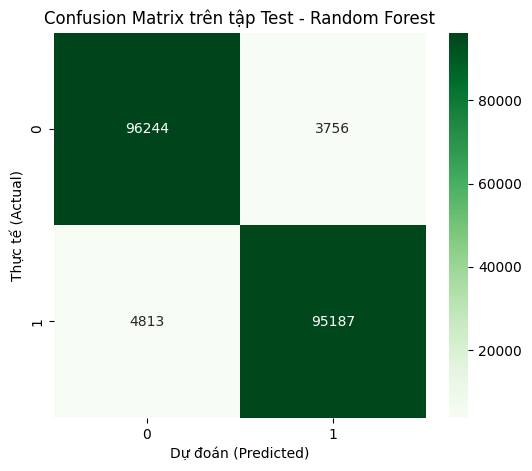

In [23]:
print("--- Đang load dữ liệu Test---")

convert_to_parquet(folder_path, "test_features.jsonl", "test_data.parquet")

df_test = pd.read_parquet(
    "test_data.parquet",
    columns=top_200_features + ["Label"]
)

X_test_final = df_test[top_200_features]
y_test_final = df_test["Label"]

X_test_scaled = scaler.transform(X_test_final)

# Lấy best model từ baseline results
best_model_name = results_df["ROC AUC"].idxmax()
best_model = models[best_model_name]

print(f"Best baseline model được chọn: {best_model_name}")
print(f"Validation ROC AUC: {results_df.loc[best_model_name, 'ROC AUC']:.4f}")

y_test_pred = best_model.predict(X_test_scaled)
y_test_probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 30)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP")
print(f"Model: {best_model_name}")
print(f"Accuracy Score: {accuracy_score(y_test_final, y_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_final, y_test_probs):.4f}")
print("=" * 30)

print("\nClassification Report:")
print(classification_report(y_test_final, y_test_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test_final, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.title(f"Confusion Matrix trên tập Test - {best_model_name}")
plt.show()

In [24]:
import os
import json
import joblib
import pandas as pd
import shutil

SAVE_DIR = "/kaggle/working/baseline_deployment_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 1. Lưu danh sách feature
# =========================

features_path = os.path.join(SAVE_DIR, "features_list.json")

with open(features_path, "w", encoding="utf-8") as f:
    json.dump(top_200_features, f, ensure_ascii=False, indent=4)

print(f"Đã lưu features list: {features_path}")


# =========================
# 2. Lưu scaler
# =========================

scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Đã lưu scaler: {scaler_path}")


# =========================
# 3. Lưu toàn bộ baseline models
# =========================

model_paths = {}

for model_name, model in models.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    model_path = os.path.join(SAVE_DIR, f"{safe_name}_baseline.pkl")
    joblib.dump(model, model_path)

    model_paths[model_name] = model_path
    print(f"Đã lưu baseline model {model_name}: {model_path}")


# =========================
# 4. Lưu bảng kết quả baseline
# =========================

baseline_results_path = os.path.join(SAVE_DIR, "baseline_results.csv")

results_df.to_csv(baseline_results_path)

print(f"Đã lưu baseline results: {baseline_results_path}")


# =========================
# 5. Tìm baseline model tốt nhất theo ROC AUC
# =========================

best_model_name = results_df["ROC AUC"].idxmax()
best_model = models[best_model_name]

best_model_path = os.path.join(SAVE_DIR, "best_baseline_model.pkl")
joblib.dump(best_model, best_model_path)

print("\nBEST BASELINE MODEL:")
print("Tên model:", best_model_name)
print("Đường dẫn:", best_model_path)


# =========================
# 6. Lưu metadata deploy
# =========================

metadata = {
    "model_type": "Baseline",
    "best_model_name": best_model_name,
    "feature_file": "features_list.json",
    "scaler_file": "scaler.pkl",
    "best_model_file": "best_baseline_model.pkl",
    "all_model_files": {
        name: os.path.basename(path)
        for name, path in model_paths.items()
    },
    "metrics_file": "baseline_results.csv",
    "target_column": "Label",
    "num_features": len(top_200_features)
}

metadata_path = os.path.join(SAVE_DIR, "deployment_metadata.json")

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"Đã lưu deployment metadata: {metadata_path}")


# =========================
# 7. Lưu một bundle chứa tất cả baseline
# =========================

deployment_bundle = {
    "model_type": "Baseline",
    "best_model_name": best_model_name,
    "best_model": best_model,
    "all_models": models,
    "scaler": scaler,
    "features": top_200_features,
    "metadata": metadata
}

bundle_path = os.path.join(SAVE_DIR, "baseline_deployment_bundle.pkl")
joblib.dump(deployment_bundle, bundle_path)

print(f"Đã lưu deployment bundle: {bundle_path}")


# =========================
# 8. Zip toàn bộ để download
# =========================

zip_path = "/kaggle/working/baseline_deployment_artifacts.zip"

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=SAVE_DIR
)

print("\nHoàn tất!")
print(f"File zip để download: {zip_path}")

Đã lưu features list: /kaggle/working/baseline_deployment_artifacts/features_list.json
Đã lưu scaler: /kaggle/working/baseline_deployment_artifacts/scaler.pkl
Đã lưu baseline model Logistic Regression: /kaggle/working/baseline_deployment_artifacts/logistic_regression_baseline.pkl
Đã lưu baseline model Random Forest: /kaggle/working/baseline_deployment_artifacts/random_forest_baseline.pkl
Đã lưu baseline model LightGBM: /kaggle/working/baseline_deployment_artifacts/lightgbm_baseline.pkl
Đã lưu baseline model AdaBoost: /kaggle/working/baseline_deployment_artifacts/adaboost_baseline.pkl
Đã lưu baseline model CatBoost: /kaggle/working/baseline_deployment_artifacts/catboost_baseline.pkl
Đã lưu baseline model XGBoost: /kaggle/working/baseline_deployment_artifacts/xgboost_baseline.pkl
Đã lưu baseline results: /kaggle/working/baseline_deployment_artifacts/baseline_results.csv

BEST BASELINE MODEL:
Tên model: Random Forest
Đường dẫn: /kaggle/working/baseline_deployment_artifacts/best_baseline_m

In [27]:
#Khi deploy, bạn có thể load nhanh bằng bundle:
import joblib

bundle_path = "/kaggle/working/baseline_deployment_artifacts/baseline_deployment_bundle.pkl"

bundle = joblib.load(bundle_path)

model = bundle["best_model"]
scaler = bundle["scaler"]
features = bundle["features"]

X_input = df_test[features]
X_input_scaled = scaler.transform(X_input)

pred = model.predict(X_input_scaled)
prob = model.predict_proba(X_input_scaled)[:, 1]